# Nhận diện khuôn mặt với MobileFaceNet & ArcFace


### 1. Khởi tạo & Tối ưu Hệ thống

In [ ]:
# 1. CÀI ĐẶT MÔI TRƯỜNG & THƯ VIỆN (SETUP)
import os
# Tối ưu hóa cấp phát bộ nhớ GPU để tránh lỗi OOM (Out Of Memory)
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

# Kết nối Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Import các thư viện
import time
import math
import random
import shutil
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision

# Thiết lập Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Kích hoạt Mixed Precision
mixed_precision.set_global_policy("mixed_bfloat16")
AUTOTUNE = tf.data.AUTOTUNE

print(f"Phiên bản TensorFlow : {tf.__version__}")
print(f"Chính sách Precision : {mixed_precision.global_policy()}")
print(f"Danh sách GPU        : {tf.config.list_physical_devices('GPU')}")


Mounted at /content/drive
Phiên bản TensorFlow : 2.20.0
Chính sách Precision : <DTypePolicy "mixed_bfloat16">
Danh sách GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 2. Cấu hình Siêu tham số
- **Kích thước ảnh:** 112x112, xuất ra vector 256 chiều.
- **Hàm Loss ArcFace:** Cài đặt Margin=0.45, Scale=64.0 giúp phân loại ranh giới các khuôn mặt khắt khe và chính xác hơn.
- **Huấn luyện:** Batch Size lớn (4096) để mô hình học ổn định.

In [ ]:
# 2. CẤU HÌNH SIÊU THAM SỐ (HYPERPARAMETERS & CONFIG)

RUN_DIR = "/content/drive/MyDrive/MobileFaceNet/models/mobilefacenet_arcface"
DATASET_ARCHIVE = "/content/drive/MyDrive/MobileFaceNet/dataset/dataset_ms1mv3.tar.gz"
DATASET_ROOT = "/content/dataset_ms1mv3"

FORCE_EXTRACT = False
FORCE_REBUILD_MANIFEST = False #True

# CẤU HÌNH MÔ HÌNH
IMAGE_SIZE = 112
EMBEDDING_SIZE = 256
WIDTH_MULT = 1.0

# Cấu hình phân lớp ArcFace
ARCFACE_SCALE = 64.0
ARCFACE_MARGIN = 0.40

# CẤU HÌNH HUẤN LUYỆN
BATCH_SIZE = 2048
EPOCHS = 70
SHUFFLE_BUFFER_SIZE = 100_000

# Thuật toán tối ưu (Optimizer) & Lịch trình Learning Rate (Cosine Annealing)
BASE_LR = 0.15
WARMUP_START_LR = 0.001
WARMUP_EPOCHS = 7
MIN_LR = 1e-5
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

# CẤU HÌNH DỮ LIỆU
# Trích xuất 3 ảnh/ID cho tập Validation
VAL_IMAGES_PER_CLASS = 3
IMG_EXTS = {".jpg", ".jpeg", ".png"}

Path(RUN_DIR).mkdir(parents=True, exist_ok=True)

print("--- TÓM TẮT CẤU HÌNH ---")
print(f"Thư mục Output   : {RUN_DIR}")
print(f"Kiến trúc mạng   : MobileFaceNet (width_mult={WIDTH_MULT}) | Embedding: {EMBEDDING_SIZE}D")
print(f"Tham số ArcFace  : Scale={ARCFACE_SCALE}, Margin={ARCFACE_MARGIN}")
print(f"Cấu hình Train   : {EPOCHS} Epochs | Batch={BATCH_SIZE}")
print(f"Tốc độ học (LR)  : Cosine Decay từ {BASE_LR} -> {MIN_LR} (Warmup {WARMUP_EPOCHS} epochs)")

--- TÓM TẮT CẤU HÌNH ---
Thư mục Output   : /content/drive/MyDrive/MobileFaceNet/models/mobilefacenet_arcface
Kiến trúc mạng   : MobileFaceNet (width_mult=1.0) | Embedding: 256D
Tham số ArcFace  : Scale=64.0, Margin=0.4
Cấu hình Train   : 70 Epochs | Batch=2048
Tốc độ học (LR)  : Cosine Decay từ 0.15 -> 1e-05 (Warmup 7 epochs)


### Quản lý Dữ liệu

In [ ]:
# 3. GIẢI NÉN DATASET

def extract_dataset(archive_path, extract_to):
    archive = Path(archive_path)
    root = Path(extract_to)

    if root.exists() and not FORCE_EXTRACT:
        print(f"[INFO] Dataset đã tồn tại tại {root}. Bỏ qua giải nén.")
        return

    if FORCE_EXTRACT and root.exists():
        print(f"[INFO] Xóa thư mục cũ {root}...")
        shutil.rmtree(root)

    if not archive.exists():
        raise FileNotFoundError(f"[ERROR] Không tìm thấy file nén: {archive}")

    print(f"[INFO] Đang giải nén {archive.name} về /content ...")
    subprocess.run(["tar", "-xzf", str(archive), "-C", "/content"], check=True)
    print(f"[INFO] Giải nén thành công: {root}")

extract_dataset(DATASET_ARCHIVE, DATASET_ROOT)

[INFO] Dataset đã tồn tại tại /content/dataset_ms1mv3. Bỏ qua giải nén.


In [ ]:
# 4. TẠO DATA MANIFEST (TRAIN/VAL)

MANIFEST_DIR = Path(RUN_DIR) / "manifests"
TRAIN_MANIFEST = MANIFEST_DIR / "train.tsv"
VAL_MANIFEST = MANIFEST_DIR / "val.tsv"
CLASS_NAMES_TXT = MANIFEST_DIR / "class_names.txt"

MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

def build_manifests(dataset_dir):
    print("[INFO] Đang tạo danh sách dữ liệu (Manifest)...")
    rng = random.Random(SEED)
    identity_dirs = sorted([p for p in Path(dataset_dir).iterdir() if p.is_dir()])

    train_records, val_records, class_names = [], [], []

    for label, identity_dir in enumerate(identity_dirs):
        class_names.append(identity_dir.name)
        images = sorted(str(p) for p in identity_dir.iterdir() if p.suffix.lower() in IMG_EXTS)
        rng.shuffle(images)

        # Tách tập Validation và Train
        val_records.extend([f"{img}\t{label}\n" for img in images[:VAL_IMAGES_PER_CLASS]])
        train_records.extend([f"{img}\t{label}\n" for img in images[VAL_IMAGES_PER_CLASS:]])

    # Ghi ra file
    with open(TRAIN_MANIFEST, "w", encoding="utf-8") as f: f.writelines(train_records)
    with open(VAL_MANIFEST, "w", encoding="utf-8") as f: f.writelines(val_records)
    with open(CLASS_NAMES_TXT, "w", encoding="utf-8") as f: f.write("\n".join(class_names))

    return len(class_names), len(train_records), len(val_records)

def get_manifest_stats():
    count_lines = lambda p: sum(1 for _ in open(p, "r", encoding="utf-8"))
    return count_lines(CLASS_NAMES_TXT), count_lines(TRAIN_MANIFEST), count_lines(VAL_MANIFEST)

# Kiểm tra xem có cần build lại không
need_build = (
    FORCE_REBUILD_MANIFEST or
    not all(p.exists() for p in [TRAIN_MANIFEST, VAL_MANIFEST, CLASS_NAMES_TXT])
)

if need_build:
    NUM_CLASSES, TRAIN_IMAGES, VAL_IMAGES = build_manifests(DATASET_ROOT)
else:
    print("[INFO] Sử dụng Manifest đã có sẵn.")
    NUM_CLASSES, TRAIN_IMAGES, VAL_IMAGES = get_manifest_stats()

print(f"Số lượng Identities (Classes): {NUM_CLASSES:,}")
print(f"Ảnh Huấn luyện (Train)       : {TRAIN_IMAGES:,}")
print(f"Ảnh Kiểm thử (Validation)    : {VAL_IMAGES:,}")

[INFO] Sử dụng Manifest đã có sẵn.
Số lượng Identities (Classes): 57,344
Ảnh Huấn luyện (Train)       : 2,121,728
Ảnh Kiểm thử (Validation)    : 172,032


### Tối ưu Đọc Dữ liệu (Data Pipeline)
Đóng gói hàng triệu ảnh thành định dạng **TFRecord** để tăng tốc độ đọc từ ổ cứng. Kết hợp làm phong phú dữ liệu (Data Augmentation - lật, chỉnh sáng) tự động để mô hình học tổng quát tốt hơn.

In [ ]:
TFRECORD_DIR = Path("/content/tfrecords")
DRIVE_BACKUP_PATH = Path("/content/drive/MyDrive/MobileFaceNet/dataset/tfrecords_ms1m.tar.gz")

if DRIVE_BACKUP_PATH.exists():
    if not TFRECORD_DIR.exists() or not any(TFRECORD_DIR.iterdir()):
        print("[INFO] Đang giải nén từ Drive về /content/tfrecords")
        TFRECORD_DIR.mkdir(parents=True, exist_ok=True)
        subprocess.run(["tar", "-xzf", str(DRIVE_BACKUP_PATH), "-C", "/content"], check=True)
        print("[INFO] Giải nén thành công!")
    else:
        print("[INFO] Thư mục /content/tfrecords đã có dữ liệu, bỏ qua giải nén.")
else:
    print(f"[INFO] Không tìm thấy bản backup tại {DRIVE_BACKUP_PATH}, cần tạo mới TFRecord.")
    TFRECORD_DIR.mkdir(parents=True, exist_ok=True)


[INFO] Đang giải nén từ Drive về /content/tfrecords
[INFO] Giải nén thành công!


In [ ]:
# 5. TF.DATA PIPELINE (TỐI ƯU I/O VỚI TFRECORD)

TFRECORD_DIR = Path("/content/tfrecords")
#TFRECORD_DIR.mkdir(parents=True, exist_ok=True)

def _bytes_feature(value):
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

def _int64_feature(value):
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[value]))

def create_tfrecords(manifest_path, output_prefix, num_shards):
    with open(manifest_path, "r", encoding="utf-8") as f:
        lines = [line.strip().split("\t") for line in f if line.strip()]

    existing_shards = list(TFRECORD_DIR.glob(f"{output_prefix}_*.tfrec"))
    if len(existing_shards) == num_shards:
        print(f"[INFO] Đã tìm thấy {num_shards} shards cho '{output_prefix}' tại /content. Bỏ qua tạo mới.")
        return

    print(f"[INFO] Đang tạo {num_shards} TFRecord shards cho '{output_prefix}' (Tổng: {len(lines)} ảnh)...")
    shard_size = math.ceil(len(lines) / num_shards)

    start_time = time.time()
    for shard_id in range(num_shards):
        shard_path = TFRECORD_DIR / f"{output_prefix}_{shard_id:03d}.tfrec"
        if shard_path.exists(): continue

        shard_lines = lines[shard_id * shard_size : (shard_id + 1) * shard_size]
        with tf.io.TFRecordWriter(str(shard_path)) as writer:
            for img_path, label in shard_lines:
                try:
                    with open(img_path, "rb") as f_img:
                        image_bytes = f_img.read()

                    feature = {
                        "image": _bytes_feature(image_bytes),
                        "label": _int64_feature(int(label))
                    }
                    example = tf.train.Example(features=tf.train.Features(feature=feature))
                    writer.write(example.SerializeToString())
                except Exception:
                    pass
        print(f"\r  -> Đã ghi xong shard {shard_id + 1}/{num_shards}", end="")

# Chạy tạo TFRecord

# create_tfrecords(TRAIN_MANIFEST, "train", num_shards=100)
# create_tfrecords(VAL_MANIFEST, "val", num_shards=10)

#  PIPELINE ĐỌC DỮ LIỆU
def parse_tfrecord(example_proto, training=False):
    feature_description = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "label": tf.io.FixedLenFeature([], tf.int64),
    }
    parsed = tf.io.parse_single_example(example_proto, feature_description)

    image = tf.io.decode_jpeg(parsed["image"], channels=3)
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])
    image = tf.cast(image, tf.float32)

    # Data Augmentation
    if training:
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, max_delta=16.0)
        image = tf.image.random_contrast(image, lower=0.90, upper=1.10)
        image = tf.image.random_saturation(image, lower=0.90, upper=1.10)
        image = tf.clip_by_value(image, 0.0, 255.0)

    # Chuẩn hóa ảnh về [-1, 1]
    image = (image - 127.5) / 128.0
    label = tf.cast(parsed["label"], tf.int32)
    return image, label

def make_tfrecord_dataset(pattern, training=False):
    filenames = tf.data.Dataset.list_files(str(TFRECORD_DIR / pattern), shuffle=training)
    ds = filenames.interleave(
        lambda x: tf.data.TFRecordDataset(x, num_parallel_reads=AUTOTUNE),
        cycle_length=AUTOTUNE,
        num_parallel_calls=AUTOTUNE,
        deterministic=False
    )

    if training:
        ds = ds.shuffle(SHUFFLE_BUFFER_SIZE, seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(lambda x: parse_tfrecord(x, training), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)

    # ArcFace yêu cầu input là tuple: ((image, label), label)
    ds = ds.map(lambda image, label: ((image, label), label), num_parallel_calls=AUTOTUNE)

    options = tf.data.Options()
    options.deterministic = False
    ds = ds.with_options(options)
    return ds.prefetch(AUTOTUNE)

# Khởi tạo Datasets
train_ds = make_tfrecord_dataset("train_*.tfrec", training=True).repeat()
val_ds = make_tfrecord_dataset("val_*.tfrec", training=False)

# Tính toán số bước chạy (steps)
steps_per_epoch = math.ceil(TRAIN_IMAGES / BATCH_SIZE)
validation_steps = math.ceil(VAL_IMAGES / BATCH_SIZE)

print("\n--- THÔNG TIN DATASET ---")
print(f"Steps per epoch  : {steps_per_epoch}")
print(f"Validation steps : {validation_steps}")


--- THÔNG TIN DATASET ---
Steps per epoch  : 1036
Validation steps : 84


### Kiến trúc Mô hình
Gồm 2 phần chính:
- **Backbone (MobileFaceNet):** Mạng lõi rất nhẹ và nhanh, dùng để rút trích hình ảnh khuôn mặt thành vector (danh sách các con số).
- **Head (ArcFace Loss):** Hàm tối ưu đặc biệt giúp kéo vector của ảnh cùng người lại gần nhau và đẩy ảnh khác người ra xa.

In [ ]:
# 6. KIẾN TRÚC MÔ HÌNH (MOBILEFACENET & ARCFACE)

#  HELPER FUNCTIONS
def make_divisible(v, divisor=8):
    return int(math.ceil(v / divisor) * divisor)

def ch(v):
    return make_divisible(v * WIDTH_MULT)

def conv_bn_prelu(x, filters, kernel_size=1, stride=1, name="conv"):
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding="same", use_bias=False, name=f"{name}_conv")(x)
    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    return layers.PReLU(shared_axes=[1, 2], name=f"{name}_prelu")(x)

def dw_bn_prelu(x, kernel_size=3, stride=1, name="dw"):
    x = layers.DepthwiseConv2D(kernel_size, strides=stride, padding="same", use_bias=False, name=f"{name}_dw")(x)
    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    return layers.PReLU(shared_axes=[1, 2], name=f"{name}_prelu")(x)

def bottleneck(x, out_channels, expansion, stride, name):
    in_channels = int(x.shape[-1])
    shortcut = x

    x = conv_bn_prelu(x, in_channels * expansion, 1, 1, name=f"{name}_expand")
    x = dw_bn_prelu(x, 3, stride, name=f"{name}_dw")
    x = layers.Conv2D(out_channels, 1, padding="same", use_bias=False, name=f"{name}_project_conv")(x)
    x = layers.BatchNormalization(name=f"{name}_project_bn")(x)

    if stride == 1 and in_channels == out_channels:
        x = layers.Add(name=f"{name}_add")([shortcut, x])
    return x

# CUSTOM LAYERS
@tf.keras.utils.register_keras_serializable()
class L2Normalize(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(dtype="float32", **kwargs)

    def call(self, inputs):
        return tf.nn.l2_normalize(tf.cast(inputs, tf.float32), axis=1)

@tf.keras.utils.register_keras_serializable()
class ArcMarginProduct(layers.Layer):
    """Lớp phân loại ArcFace (Additive Angular Margin Loss)"""
    def __init__(self, num_classes, scale=64.0, margin=0.5, easy_margin=False, **kwargs):
        super().__init__(dtype="float32", **kwargs)
        self.num_classes = int(num_classes)
        self.scale = float(scale)
        self.margin = float(margin)
        self.easy_margin = bool(easy_margin)
        self.cos_m = math.cos(self.margin)
        self.sin_m = math.sin(self.margin)
        self.th = math.cos(math.pi - self.margin)
        self.mm = math.sin(math.pi - self.margin) * self.margin

    def build(self, input_shape):
        embedding_dim = int(input_shape[0][-1])
        self.w = self.add_weight(
            name="arcface_w", shape=(embedding_dim, self.num_classes),
            initializer="glorot_uniform", trainable=True, dtype=tf.float32,
        )

    def call(self, inputs):
        embedding, label = inputs
        embedding = tf.nn.l2_normalize(tf.cast(embedding, tf.float32), axis=1)
        weight = tf.nn.l2_normalize(self.w, axis=0)

        cosine = tf.matmul(embedding, weight)
        cosine = tf.clip_by_value(cosine, -1.0 + 1e-7, 1.0 - 1e-7)
        sine = tf.sqrt(tf.maximum(1.0 - tf.square(cosine), 1e-7))
        phi = cosine * self.cos_m - sine * self.sin_m

        if self.easy_margin:
            phi = tf.where(cosine > 0.0, phi, cosine)
        else:
            phi = tf.where(cosine > self.th, phi, cosine - self.mm)

        one_hot = tf.one_hot(tf.cast(label, tf.int32), depth=self.num_classes, dtype=tf.float32)
        logits = one_hot * phi + (1.0 - one_hot) * cosine
        return logits * self.scale

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_classes": self.num_classes, "scale": self.scale,
            "margin": self.margin, "easy_margin": self.easy_margin,
        })
        return config

# --- BUILD MODELS ---
def build_mobilefacenet():
    """Xây dựng mạng Backbone MobileFaceNet"""
    image = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3), name="image")

    # Block 1: 112x112 -> 56x56
    x = conv_bn_prelu(image, ch(64), 3, 2, name="stem")
    x = dw_bn_prelu(x, 3, 1, name="stem_dw")

    # Block 2: 56x56 -> 28x28
    block_id = 0
    for i in range(5):
        x = bottleneck(x, ch(64), expansion=2, stride=2 if i == 0 else 1, name=f"bneck_{block_id}")
        block_id += 1

    # Block 3: 28x28 -> 14x14
    x = bottleneck(x, ch(128), expansion=4, stride=2, name=f"bneck_{block_id}")
    block_id += 1
    for _ in range(6):
        x = bottleneck(x, ch(128), expansion=2, stride=1, name=f"bneck_{block_id}")
        block_id += 1

    # Block 4: 14x14 -> 7x7
    x = bottleneck(x, ch(128), expansion=4, stride=2, name=f"bneck_{block_id}")
    block_id += 1
    for _ in range(2):
        x = bottleneck(x, ch(128), expansion=2, stride=1, name=f"bneck_{block_id}")
        block_id += 1

    # GDC Head: 7x7 -> 1x1 -> Embedding
    x = conv_bn_prelu(x, ch(512), 1, 1, name="conv_1x1")
    x = layers.DepthwiseConv2D(7, padding="valid", use_bias=False, name="gdc_dw")(x)
    x = layers.BatchNormalization(name="gdc_bn")(x)
    x = layers.Conv2D(EMBEDDING_SIZE, 1, use_bias=False, name="embedding_conv")(x)
    x = layers.BatchNormalization(name="embedding_bn")(x)
    x = layers.Flatten(name="flatten")(x)
    embedding = L2Normalize(name="embedding")(x)

    return tf.keras.Model(image, embedding, name="MobileFaceNet")

def build_arcface_model():
    """Xây dựng mô hình huấn luyện tổng thể (Backbone + ArcFace Head)"""
    backbone = build_mobilefacenet()

    image = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3), name="train_image")
    label = layers.Input(shape=(), dtype=tf.int32, name="train_label")

    embedding = backbone(image)
    logits = ArcMarginProduct(
        NUM_CLASSES,
        scale=ARCFACE_SCALE,
        margin=ARCFACE_MARGIN,
        name="arcface_head",
    )([embedding, label])

    train_model = tf.keras.Model([image, label], logits, name="MobileFaceNet_ArcFace")
    embedding_model = tf.keras.Model(image, embedding, name="MobileFaceNet_Embedding")
    return train_model, embedding_model

# Khởi tạo mô hình
train_model, embedding_model = build_arcface_model()
train_model.summary()
print("Embedding model params:", embedding_model.count_params())
print("Train model params:", train_model.count_params())


Model: "MobileFaceNet_ArcFace"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ train_image         │ (None, 112, 112,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileFaceNet       │ (None, 256)       │  1,088,768 │ train_image[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ train_label         │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ arcface_head        │ (None, 57344)     │ 14,680,064 │ MobileFaceNet[0]… │
│ (ArcMarginProduct)  │                   │            │ train_label[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,768,832 (60.15 MB)

 Trainable params: 15,748,992 (60.08 MB)

 Non-trainable params: 19,840 (77.50 KB)

Embedding model params: 1088768
Train model params: 15768832


### Chiến lược Huấn luyện
Sử dụng lịch trình thay đổi tốc độ học (Learning Rate):
- **Warmup:** Tăng từ từ ở các vòng đầu để tránh sốc khi trọng số còn mới.
- **Cosine Annealing:** Giảm mượt mà về cuối để tinh chỉnh mô hình hội tụ điểm tốt nhất.
- Tự động lưu lại phiên bản tốt nhất (Best weights) trên tập Validation.

In [ ]:
# 7. THIẾT LẬP HUẤN LUYỆN (COMPILE MODEL & CALLBACKS)

import math

def lr_schedule(epoch, current_lr):
    """
    Chiến lược Learning Rate: Warmup kết hợp Cosine Annealing.
    Giúp mô hình khởi động an toàn và hội tụ đạt độ chính xác cao nhất.
    """
    epoch_number = epoch + 1
    if epoch_number <= WARMUP_EPOCHS:
        progress = (epoch_number - 1) / max(1, WARMUP_EPOCHS - 1)
        return WARMUP_START_LR + progress * (BASE_LR - WARMUP_START_LR)

    progress = (epoch_number - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return MIN_LR + 0.5 * (BASE_LR - MIN_LR) * (1.0 + math.cos(math.pi * progress))

#  KHỞI TẠO TỐI ƯU HÓA (OPTIMIZER) & BIÊN DỊCH (COMPILE)
optimizer = tf.keras.optimizers.SGD(
    learning_rate=WARMUP_START_LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
    nesterov=True,
)

train_model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="acc")],
    steps_per_execution=100,  # Tối ưu hóa luồng thực thi trên GPU
)

# THIẾT LẬP HỆ THỐNG GIÁM SÁT VÀ LƯU TRỮ (CALLBACKS)
BEST_WEIGHTS = str(Path(RUN_DIR) / "best.weights.h5")
LATEST_WEIGHTS = str(Path(RUN_DIR) / "latest.weights.h5")
LOG_CSV = str(Path(RUN_DIR) / "training_log.csv")
BACKUP_DIR = str(Path(RUN_DIR) / "backup")
TENSORBOARD_DIR = str(Path(RUN_DIR) / "tensorboard_logs")

callbacks = [
    tf.keras.callbacks.LearningRateScheduler(lr_schedule, verbose=0),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, verbose=0, restore_best_weights=False),
    tf.keras.callbacks.ModelCheckpoint(BEST_WEIGHTS, monitor="val_loss", mode="min", save_best_only=True, save_weights_only=True, verbose=0),
    tf.keras.callbacks.ModelCheckpoint(LATEST_WEIGHTS, save_best_only=False, save_weights_only=True, verbose=0),
    tf.keras.callbacks.CSVLogger(LOG_CSV, append=True),
    tf.keras.callbacks.BackupAndRestore(backup_dir=BACKUP_DIR),
    tf.keras.callbacks.TensorBoard(log_dir=TENSORBOARD_DIR, histogram_freq=0)
]

In [ ]:
# 8. THỰC THI HUẤN LUYỆN (TRAINING)

print("Bắt đầu quá trình huấn luyện mô hình...")

history = train_model.fit(
    train_ds,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=1,
)

Bắt đầu quá trình huấn luyện mô hình...
Epoch 1/70
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 1977s 2s/step - acc: 0.0000e+00 - loss: 35.7671 - val_acc: 0.0000e+00 - val_loss: 36.7714 - learning_rate: 0.0010
Epoch 2/70
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 1244s 1s/step - acc: 0.0120 - loss: 29.9150 - val_acc: 0.0027 - val_loss: 32.2345 - learning_rate: 0.0258
Epoch 3/70
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 1241s 1s/step - acc: 0.0906 - loss: 17.1863 - val_acc: 0.0310 - val_loss: 17.9353 - learning_rate: 0.0507
Epoch 4/70
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 1250s 1s/step - acc: 0.1800 - loss: 11.1989 - val_acc: 0.0525 - val_loss: 15.4018 - learning_rate: 0.0755
Epoch 5/70
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 1234s 1s/step - acc: 0.2384 - loss: 9.3946 - val_acc: 0.0681 - val_loss: 13.9598 - learning_rate: 0.1003
Epoch 6/70
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 1234s 1s/step - acc: 0.2844 - loss: 8.1381 - val_acc: 0.0912 - val_loss: 12.8054 - learning_rate: 0.1252
Epoch 7/70
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 1233s 1s/step - acc: 0.3

In [ ]:
print("Bắt đầu quá trình huấn luyện mô hình...")

history = train_model.fit(
    train_ds,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=1,
)

Bắt đầu quá trình huấn luyện mô hình...
Epoch 69/70
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 1953s 2s/step - acc: 0.7071 - loss: 2.2707 - val_acc: 0.5336 - val_loss: 4.2389 - learning_rate: 1.0322e-04
Epoch 70/70
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 1238s 1s/step - acc: 0.7079 - loss: 2.2639 - val_acc: 0.5335 - val_loss: 4.2377 - learning_rate: 1.0000e-05


### Lưu trữ và Xuất Mô hình
Khôi phục trọng số tốt nhất và tách riêng phần lõi (Embedding Model). Đây chính là phần mô hình gọn nhẹ sẽ được đem đi cài đặt vào hệ thống thực tế để nhận diện khuôn mặt.

In [ ]:
# 9. LƯU TRỮ MÔ HÌNH VÀ KIỂM TRA ĐẶC TRƯNG (EMBEDDING)

FINAL_ARCFACE_WEIGHTS = str(Path(RUN_DIR) / "final_arcface.weights.h5")
EMBEDDING_WEIGHTS = str(Path(RUN_DIR) / "mobilefacenet_embedding.weights.h5")
EMBEDDING_MODEL = str(Path(RUN_DIR) / "mobilefacenet_embedding.keras")

# Phục hồi trọng số tốt nhất (Best Weights) trên tập Validation
if Path(BEST_WEIGHTS).exists():
    print(f"Loading best weights from {BEST_WEIGHTS} before export...")
    train_model.load_weights(BEST_WEIGHTS)
else:
    print("Best weights not found, using last epoch weights.")

train_model.save_weights(FINAL_ARCFACE_WEIGHTS)
embedding_model.save_weights(EMBEDDING_WEIGHTS)
embedding_model.save(EMBEDDING_MODEL)

print("Saved ArcFace weights:", FINAL_ARCFACE_WEIGHTS)
print("Saved embedding weights:", EMBEDDING_WEIGHTS)
print("Saved embedding model:", EMBEDDING_MODEL)

Loading best weights from /content/drive/MyDrive/MobileFaceNet/models/mobilefacenet_arcface/best.weights.h5 before export...
Saved ArcFace weights: /content/drive/MyDrive/MobileFaceNet/models/mobilefacenet_arcface/final_arcface.weights.h5
Saved embedding weights: /content/drive/MyDrive/MobileFaceNet/models/mobilefacenet_arcface/mobilefacenet_embedding.weights.h5
Saved embedding model: /content/drive/MyDrive/MobileFaceNet/models/mobilefacenet_arcface/mobilefacenet_embedding.keras


### Đánh giá Mô hình trên tập LFW
Thử nghiệm trên tập dữ liệu chuẩn 6.000 cặp ảnh:
- **Căn chỉnh khuôn mặt:** Dùng mạng **MTCNN** để tìm 5 điểm mốc (mắt, mũi, miệng) và cắt xoay ảnh cho thẳng.
- **Đánh giá:** Tính khoảng cách (Cosine Similarity) giữa 2 ảnh và tìm ra Ngưỡng (Threshold) tốt nhất để quyết định là "cùng một người" hay "khác người".

[INFO] Đang giải nén /content/drive/MyDrive/MobileFaceNet/dataset/test/lfw_final.tgz...


/tmp/ipykernel_11271/3013359843.py:25: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=LFW_EXTRACT_DIR)


[INFO] Giải nén hoàn tất!

[INFO] Đang đọc file pairs.txt...
[INFO] Tổng số cặp ảnh tìm thấy: 6000

[INFO] Đang tải và tiền xử lý ảnh (đã align)...


Ảnh 2 (Đối chiếu): 100%|██████████| 6000/6000 [00:01<00:00, 3471.70it/s]



[INFO] Đang đưa qua mô hình để lấy Embeddings...


Inferencing: 100%|██████████| 47/47 [00:41<00:00,  1.15it/s]



[KẾT QUẢ] Độ chính xác trên tập LFW (Offline): 96.65%
[KẾT QUẢ] Ngưỡng phân loại (Threshold) tối ưu : 0.2548



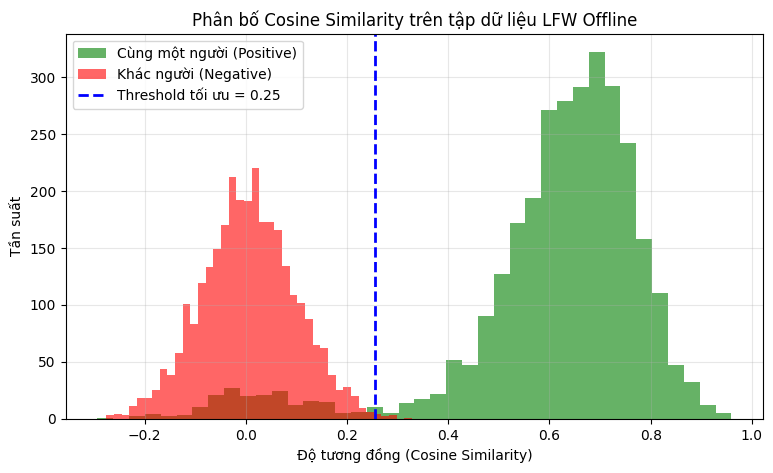

In [ ]:
# 11. ĐÁNH GIÁ TRÊN BENCHMARK LFW (OFFLINE LOCAL DATASET)

import os
import cv2
import tarfile
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, roc_curve
import matplotlib.pyplot as plt
from tqdm import tqdm

tf.keras.mixed_precision.set_global_policy('float32')

# KHAI BÁO CÁC ĐƯỜNG DẪN
LFW_TGZ_PATH = "/content/drive/MyDrive/MobileFaceNet/dataset/test/lfw_final.tgz"
PAIRS_TXT_PATH = "/content/drive/MyDrive/MobileFaceNet/dataset/test/pairs.txt"
PAIRS_DEV_TXT_PATH = "/content/drive/MyDrive/MobileFaceNet/dataset/test/pairsDevTest.txt"
LFW_EXTRACT_DIR = "/content/lfw_data"

# Bước 1: Giải nén lfw_final.tgz
if not os.path.exists(LFW_EXTRACT_DIR):
    print(f"[INFO] Đang giải nén {LFW_TGZ_PATH}...")
    os.makedirs(LFW_EXTRACT_DIR, exist_ok=True)
    with tarfile.open(LFW_TGZ_PATH, 'r:gz') as tar:
        tar.extractall(path=LFW_EXTRACT_DIR)
    print("[INFO] Giải nén hoàn tất!")
else:
    print(f"[INFO] Thư mục {LFW_EXTRACT_DIR} đã tồn tại, bỏ qua giải nén.")

# Tìm thư mục chứa ảnh thực sự bên trong lfw_data (đề phòng file nén bọc thêm 1 thư mục gốc)
search_dir = LFW_EXTRACT_DIR
subdirs = [os.path.join(LFW_EXTRACT_DIR, d) for d in os.listdir(LFW_EXTRACT_DIR) if os.path.isdir(os.path.join(LFW_EXTRACT_DIR, d))]
# Nếu bên trong lfw_data có 1 thư mục duy nhất (ví dụ 'lfw' hay 'lfw_112x112') chứa dữ liệu
if len(subdirs) == 1 and not any(os.path.isfile(os.path.join(LFW_EXTRACT_DIR, f)) for f in os.listdir(LFW_EXTRACT_DIR)):
    search_dir = subdirs[0]

# Bước 2: Phân tích file pairs.txt
def parse_pairs(pairs_path, img_root_dir):
    with open(pairs_path, 'r') as f:
        lines = f.readlines()[1:] # Bỏ qua dòng đầu chứa metadata (như: 10 300)

    pairs = []
    labels = []

    for line in lines:
        parts = line.strip().split()
        if len(parts) == 3: # Cặp Positive: name id1 id2
            name, id1, id2 = parts
            img1 = f"{name}_{int(id1):04d}.jpg"
            img2 = f"{name}_{int(id2):04d}.jpg"
            path1 = os.path.join(img_root_dir, name, img1)
            path2 = os.path.join(img_root_dir, name, img2)
            pairs.append((path1, path2))
            labels.append(1)
        elif len(parts) == 4: # Cặp Negative: name1 id1 name2 id2
            name1, id1, name2, id2 = parts
            img1 = f"{name1}_{int(id1):04d}.jpg"
            img2 = f"{name2}_{int(id2):04d}.jpg"
            path1 = os.path.join(img_root_dir, name1, img1)
            path2 = os.path.join(img_root_dir, name2, img2)
            pairs.append((path1, path2))
            labels.append(0)

    return pairs, np.array(labels)

print("\n[INFO] Đang đọc file pairs.txt...")
pairs, labels = parse_pairs(PAIRS_TXT_PATH, search_dir)
print(f"[INFO] Tổng số cặp ảnh tìm thấy: {len(pairs)}")

# Bước 3: Đọc và Tiền xử lý Ảnh
def load_and_preprocess(img_path):
    img = cv2.imread(img_path)
    if img is None:
        # Khắc phục nếu ảnh không tồn tại
        return np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.float32)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE)) # Đảm bảo size 112x112
    img = (img.astype(np.float32) - 127.5) / 128.0  # Chuẩn hóa về [-1, 1]
    return img

print("\n[INFO] Đang tải và tiền xử lý ảnh (đã align)...")
imgs1 = np.array([load_and_preprocess(p[0]) for p in tqdm(pairs, desc="Ảnh 1 (Tham chiếu)")])
imgs2 = np.array([load_and_preprocess(p[1]) for p in tqdm(pairs, desc="Ảnh 2 (Đối chiếu)")])

# Bước 4: Trích xuất Embedding
print("\n[INFO] Đang đưa qua mô hình để lấy Embeddings...")
batch_size = 128
emb1_list, emb2_list = [], []

for i in tqdm(range(0, len(imgs1), batch_size), desc="Inferencing"):
    emb1_list.append(embedding_model(imgs1[i:i+batch_size], training=False))
    emb2_list.append(embedding_model(imgs2[i:i+batch_size], training=False))

emb1 = np.concatenate(emb1_list, axis=0)
emb2 = np.concatenate(emb2_list, axis=0)

# Bước 5: Đánh giá Cosine Similarity
sims = np.sum(emb1 * emb2, axis=1)

fpr, tpr, thresholds = roc_curve(labels, sims)
best_acc, best_thresh = 0, 0

for thresh in thresholds:
    preds = (sims >= thresh).astype(int)
    acc = accuracy_score(labels, preds)
    if acc > best_acc:
        best_acc, best_thresh = acc, thresh

print("\n" + "="*50)
print(f"[KẾT QUẢ] Độ chính xác trên tập LFW (Offline): {best_acc*100:.2f}%")
print(f"[KẾT QUẢ] Ngưỡng phân loại (Threshold) tối ưu : {best_thresh:.4f}")
print("="*50 + "\n")

# Vẽ biểu đồ
plt.figure(figsize=(9, 5))
plt.hist(sims[labels == 1], bins=40, alpha=0.6, label='Cùng một người (Positive)', color='green')
plt.hist(sims[labels == 0], bins=40, alpha=0.6, label='Khác người (Negative)', color='red')
plt.axvline(best_thresh, color='blue', linestyle='dashed', linewidth=2, label=f'Threshold tối ưu = {best_thresh:.2f}')
plt.title('Phân bố Cosine Similarity trên tập dữ liệu LFW Offline')
plt.xlabel('Độ tương đồng (Cosine Similarity)')
plt.ylabel('Tần suất')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# 12. THỬ NGHIỆM VỚI NGƯỠNG (THRESHOLD) TÙY CHỈNH

thresh_custom = 0.50
preds_custom = (sims >= thresh_custom).astype(int)

acc_custom = accuracy_score(labels, preds_custom)
print(f"[INFO] Độ chính xác (Accuracy) trên LFW với ngưỡng cố định {thresh_custom}: {acc_custom*100:.2f}%")

[INFO] Độ chính xác (Accuracy) trên LFW với ngưỡng cố định 0.5: 92.00%


Đang tải mô hình từ Drive...
Khởi tạo MTCNN...

👉 Vui lòng tải lên 2 bức ảnh để kiểm tra độ tương đồng...


Saving Screenshot 2026-05-08 145846.png to Screenshot 2026-05-08 145846 (5).png
Saving Screenshot 2026-05-07 161243.png to Screenshot 2026-05-07 161243 (3).png

Đang xử lý và trích xuất đặc trưng...
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


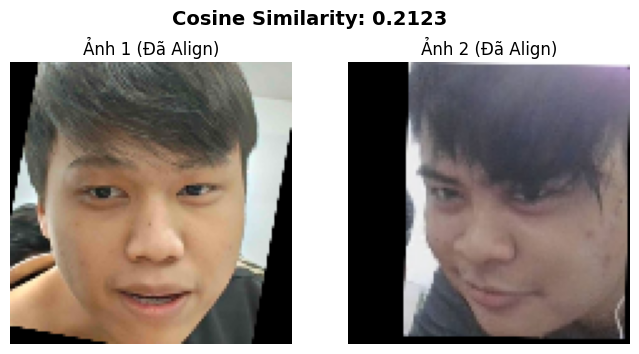


❌ KẾT LUẬN: KHÁC NGƯỜI (Độ tương đồng: 0.2123 < 0.28)


In [ ]:
!pip install mtcnn

import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import files
from mtcnn import MTCNN
from skimage import transform as trans

# Khai báo lại lớp L2Normalize để Keras có thể load mô hình
@tf.keras.utils.register_keras_serializable()
class L2Normalize(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        kwargs.pop('dtype', None) # Xóa dtype nếu có trong kwargs để tránh trùng lặp
        super().__init__(dtype="float32", **kwargs)

    def call(self, inputs):
        return tf.nn.l2_normalize(tf.cast(inputs, tf.float32), axis=1)

# 1. Load mô hình từ Drive
print("Đang tải mô hình từ Drive...")
EMBEDDING_MODEL = "/content/drive/MyDrive/MobileFaceNet/models/mobilefacenet_arcface/mobilefacenet_embedding.keras"
loaded_model = tf.keras.models.load_model(EMBEDDING_MODEL, custom_objects={'L2Normalize': L2Normalize}, compile=False)

print("Khởi tạo MTCNN...")
detector = MTCNN()

# 2. Các hàm hỗ trợ Alignment
REFERENCE_FACIAL_POINTS = np.array([
    [38.2946, 51.6963], [73.5318, 51.5014], [56.0252, 71.7366],
    [41.5493, 92.3655], [70.7299, 92.2041]
], dtype=np.float32)

def align_face_custom(img, landmarks):
    src = np.array([
        landmarks['left_eye'], landmarks['right_eye'], landmarks['nose'],
        landmarks['mouth_left'], landmarks['mouth_right']
    ], dtype=np.float32)
    tform = trans.SimilarityTransform()
    tform.estimate(src, REFERENCE_FACIAL_POINTS)
    M = tform.params[0:2, :]
    return cv2.warpAffine(img, M, (112, 112), borderValue=0.0)

def process_uploaded_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = detector.detect_faces(img)

    if len(results) > 0:
        best_face = max(results, key=lambda b: b['confidence'])
        aligned = align_face_custom(img, best_face['keypoints'])
    else:
        print(f"Cảnh báo: Không tìm thấy khuôn mặt trong {img_path}, sử dụng ảnh gốc (resize)!")
        aligned = cv2.resize(img, (112, 112))

    # Chuẩn hóa
    norm_img = (aligned.astype(np.float32) - 127.5) / 128.0
    return aligned, norm_img

# 3. Giao diện Upload và So sánh
print("\n👉 Vui lòng tải lên 2 bức ảnh để kiểm tra độ tương đồng...")
uploaded = files.upload()
uploaded_files = list(uploaded.keys())

if len(uploaded_files) >= 2:
    img_path1 = uploaded_files[0]
    img_path2 = uploaded_files[1]

    print("\nĐang xử lý và trích xuất đặc trưng...")
    aligned1, norm1 = process_uploaded_image(img_path1)
    aligned2, norm2 = process_uploaded_image(img_path2)

    emb1 = loaded_model.predict(np.expand_dims(norm1, axis=0))[0]
    emb2 = loaded_model.predict(np.expand_dims(norm2, axis=0))[0]

    # Tính Cosine Similarity
    similarity = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))

    # Vẽ kết quả
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(aligned1)
    axes[0].axis('off')
    axes[0].set_title("Ảnh 1 (Đã Align)")

    axes[1].imshow(aligned2)
    axes[1].axis('off')
    axes[1].set_title("Ảnh 2 (Đã Align)")

    plt.suptitle(f"Cosine Similarity: {similarity:.4f}", fontsize=14, fontweight='bold')
    plt.show()

    # Ngưỡng tối ưu dựa vào phần đánh giá LFW ở trên (ví dụ ~0.28)
    threshold = 0.28
    if similarity >= threshold:
        print(f"\n✅ KẾT LUẬN: CÙNG MỘT NGƯỜI (Độ tương đồng: {similarity:.4f} >= {threshold})")
    else:
        print(f"\n❌ KẾT LUẬN: KHÁC NGƯỜI (Độ tương đồng: {similarity:.4f} < {threshold})")
else:
    print("\nVui lòng tải lên ít nhất 2 ảnh để có thể so sánh!")
